In [1]:
from copy import deepcopy
from scipy import stats
from scipy.spatial import cKDTree
import pandas as pd
import os
import numpy as np
from tqdm import tqdm
import networkx as nx
import random
from collections import defaultdict, Counter
from typing import Dict, List, Set, Tuple, Optional
from itertools import chain, product
import bisect
from collections import defaultdict
from concurrent.futures import ProcessPoolExecutor, as_completed
import time
import warnings
warnings.filterwarnings("ignore")
seed = 1729928109

# Set the random seed for reproducibility
random.seed(seed)
np.random.seed(seed)

base_sparsified_path = r'/raid/t2/TGN_adv/sparsified_data'
dataset_name = 'uci'

original_filename = rf'ml_{dataset_name}.csv'

print(os.path.join(base_sparsified_path, dataset_name, original_filename))

orig_df = pd.read_csv(os.path.join(base_sparsified_path, dataset_name, original_filename))
# orig_df.drop(['Unnamed: 0'], axis=1, inplace=True)
orig_df['ts'] = orig_df['ts']+1082040961
orig_df.head()

/raid/t2/TGN_adv/sparsified_data/uci/ml_uci.csv


,Unnamed: 0,u,i,ts,label,idx
0,0,1,2,1082040961,0,1
1,1,3,4,1082155839,0,2
2,2,5,2,1082414391,0,3
3,3,6,7,1082439619,0,4
4,4,8,7,1082439756,0,5


#### test

In [2]:
# datasets  = ['uci', 'bitcoin', 'wikipedia', 'mooc']

# for dataset in datasets[:]:
#     original_filename = rf'ml_{dataset}.csv'
#     orig_df = pd.read_csv(os.path.join(base_sparsified_path, dataset, original_filename))
#     # select 10 random timestamps
#     timestamps = orig_df['ts'].unique()
#     selected_timestamps = np.random.choice(timestamps, 10, replace=False)
#     W = 1200*1e3
#     for i, timestamp in enumerate(timestamps):
#         gen_df = orig_df[(orig_df['ts'] >= timestamp - W) & (orig_df['ts'] <= timestamp)]
#         if len(gen_df) == 0:
#             print(f'{dataset} - {i+1} - {timestamp = }')
#             print('\tlength of all available timestamps: ', len(gen_df['ts']), ', unique timestamps: ', len(gen_df['ts'].unique()))
#             print('\tlength of unique src and dst nodes: ', gen_df['u'].nunique(), gen_df['i'].nunique())
#             print('\tlength of unique nodes', len(set(gen_df['u'].unique()).union(set(gen_df['i'].unique()))))


In [3]:
# import pandas as pd
# import numpy as np
# import os
# from tabulate import tabulate

# def create_dataset_analysis_table(base_sparsified_path, datasets=['uci', 'bitcoin', 'wikipedia', 'mooc']):
#     table_data = []
#     headers = ['Dataset', 'Sample #', 'Timestamp', 'Total Events', 'Unique Timestamps', 
#               'Unique Source Nodes', 'Unique Target Nodes', 'Total Unique Nodes']
    
#     for dataset in datasets:
#         original_filename = f'ml_{dataset}.csv'
#         orig_df = pd.read_csv(os.path.join(base_sparsified_path, dataset, original_filename))
        
#         # select 10 random timestamps
#         timestamps = orig_df['ts'].unique()
#         selected_timestamps = np.random.choice(timestamps, 10, replace=False)
#         W = 1200*1e3
        
#         for i, timestamp in enumerate(selected_timestamps):
#             gen_df = orig_df[(orig_df['ts'] >= timestamp - W) & (orig_df['ts'] <= timestamp)]
            
#             # Calculate metrics
#             total_events = len(gen_df['ts'])
#             unique_timestamps = len(gen_df['ts'].unique())
#             unique_src = gen_df['u'].nunique()
#             unique_dst = gen_df['i'].nunique()
#             total_unique_nodes = len(set(gen_df['u'].unique()).union(set(gen_df['i'].unique())))
            
#             # Add row to table data
#             table_data.append([
#                 dataset,
#                 i + 1,
#                 str(timestamp),
#                 total_events,
#                 unique_timestamps,
#                 unique_src,
#                 unique_dst,
#                 total_unique_nodes
#             ])
    
#     # Create formatted table
#     return tabulate(table_data, headers=headers, tablefmt='grid', numalign='right', floatfmt='.0f')


# print(create_dataset_analysis_table(base_sparsified_path))

In [4]:
# print(orig_df['ts'].min(), orig_df['ts'].max())

# print(sum(orig_df['ts'].isna()), len(orig_df['ts'].unique()), len(orig_df['ts']), len(orig_df['ts']) - orig_df['ts'].nunique())


# # orig_df['ts'].value_counts()

# print((15931000 - 1200*1e3))

# orig_df[orig_df['ts']  == 15931000]  # (15931000 - 1200*1e3, 15931000)

# last_active_df=orig_df[(orig_df['ts'] >= 14731000) & (orig_df['ts'] <= 15931000)]  # (15931000 - 1200*1e3, 15931000)

# print(last_active_df['ts'].min(), last_active_df['ts'].max())

# print(last_active_df['u'].nunique(), last_active_df['i'].nunique())

# last_active_df

#### start from here

In [5]:
val_ratio = test_ratio = 0.15

val_time, test_time = list(np.quantile(orig_df.ts, [(1 - val_ratio - test_ratio), (1 - test_ratio)]))

orig_df = orig_df[orig_df['ts'] < val_time]

In [6]:
# sparsification 
sprs_type = 'ts_tpr_remove_cosine'  # 'ts_tpr_remove_mss'
upto = 0.7

sprs_filename = f'{dataset_name}_{sprs_type}_sparsified_{upto}.csv'
sprs_filename

full_sprs_filepath = os.path.join(base_sparsified_path, dataset_name, sprs_type, sprs_filename)

sprs_df = pd.read_csv(full_sprs_filepath)
sprs_df['ts'] = sprs_df['ts']+1082040961
sprs_df.head()

,Unnamed: 0,u,i,ts,label,idx
0,100,73,74,1082609649,0,101
1,200,105,33,1082654503,0,201
2,500,164,8,1082790172,0,501
3,600,41,177,1082794645,0,601
4,700,41,188,1082800924,0,701


In [7]:
from hh_attack_utils import *
from hh_attack_data import *

## New Utils

### Unusable

In [8]:
# WORKING

# class NonBipartiteEdgeSelector(EdgeTimestampSelector):
#     def __init__(self,
#                  feasible_edges_dict: Dict,
#                  original_df: pd.DataFrame,
#                  degree_dict: Dict[int, int],
#                  removed_edges: Set[Tuple[int, int]],
#                  src_nodes: Set[int],
#                  dst_nodes: Set[int],
#                  time_window: int = 1200,
#                  debug: bool = False):
#         """Initialize NonBipartite Edge Selector with debug mode"""
#         super().__init__(
#             feasible_edges_dict=feasible_edges_dict,
#             original_df=original_df,
#             degree_dict=degree_dict,
#             removed_edges=removed_edges,
#             src_nodes=src_nodes,
#             dst_nodes=dst_nodes,
#             time_window=time_window
#         )
#         self.debug = debug
        
#         # Initialize C4 tracking
#         self.max_perturbations = {
#             node: self.degree_dict[node] # C4: ~10% of degree
#             for node in self.degree_dict
#         }
#         self.node_perturbations = defaultdict(int)
        
#         # Initialize C3 tracking
#         self._initialize_activity_windows()
        
#         if self.debug:
#             print("Initialization complete:")
#             print(f"Max edges: {self.max_edges}")
#             print("Max perturbations per node (sample):")
#             sample_nodes = list(self.max_perturbations.keys())[:5]
#             for node in sample_nodes:
#                 print(f"\tNode {node}: {self.max_perturbations[node]}")
                
#     def _initialize_activity_windows(self):
#         """Initialize node activity windows for C3 compliance"""
#         df = self.original_df
        
#         # Create node activity windows
#         self.node_activity = defaultdict(list)
#         for _, row in df.iterrows():
#             self.node_activity[row['u']].append(row['ts'])
#             self.node_activity[row['i']].append(row['ts'])
            
#         # Sort timestamps for each node
#         for node in self.node_activity:
#             self.node_activity[node].sort()
            
#         if self.debug:
#             print("\nActivity window initialization:")
#             sample_node = next(iter(self.node_activity))
#             print(f"Sample node {sample_node} activity count: {len(self.node_activity[sample_node])}")
            
#     def check_c3_compliance(self, node1: int, node2: int, timestamp: float) -> bool:
#         """Check if edge satisfies C3 (time window) constraint"""
#         window_size = self.time_window
#         window_start = timestamp - window_size
#         window_end = timestamp + window_size
        
#         times1 = self.node_activity[node1]
#         times2 = self.node_activity[node2]
        
#         if not times1 or not times2:
#             return False
            
#         # Check if both nodes are active within window
#         idx1 = bisect.bisect_left(times1, window_start)
#         if idx1 >= len(times1) or times1[idx1] > window_end:
#             return False
            
#         idx2 = bisect.bisect_left(times2, window_start)
#         if idx2 >= len(times2) or times2[idx2] > window_end:
#             return False
            
#         return True
        
#     def check_c4_compliance(self, node1: int, node2: int) -> bool:
#         """Check if edge satisfies C4 (perturbation limit) constraint"""
#         return (self.node_perturbations[node1] < self.max_perturbations[node1] and
#                 self.node_perturbations[node2] < self.max_perturbations[node2])
                
#     def _update_tracking(self, edge: Tuple[int, int]):
#         """Update all tracking after edge selection"""
#         u, v = edge
#         # Update capacity (parent tracking)
#         self.remaining_capacity[u] -= 1
#         self.remaining_capacity[v] -= 1
#         self.node_usage[u] += 1
#         self.node_usage[v] += 1
        
#         # Update perturbation counts (C4 tracking)
#         self.node_perturbations[u] += 1
#         self.node_perturbations[v] += 1
        
#         if self.debug:
#             print(f"\nTracking updated for edge ({u}, {v}):")
#             print(f"Node {u} perturbations: {self.node_perturbations[u]}/{self.max_perturbations[u]}")
#             print(f"Node {v} perturbations: {self.node_perturbations[v]}/{self.max_perturbations[v]}")
            
#     def _can_select(self, edge: Tuple[int, int], timestamps: List[int]) -> bool:
#         """Check if edge can be selected (all constraints)"""
#         u, v = edge
        
#         # Basic checks
#         if not timestamps:
#             return False
#         if self.remaining_capacity[u] <= 0 or self.remaining_capacity[v] <= 0:
#             return False
#         if edge in self.removed_edges:
#             return False
            
#         # C4 check
#         if not self.check_c4_compliance(u, v):
#             if self.debug:
#                 print(f"C4 violation for edge ({u}, {v}):")
#                 print(f"Node {u}: {self.node_perturbations[u]}/{self.max_perturbations[u]}")
#                 print(f"Node {v}: {self.node_perturbations[v]}/{self.max_perturbations[v]}")
#             return False
            
#         # C3 check for best timestamp
#         best_ts = max(timestamps)  # or other selection strategy
#         if not self.check_c3_compliance(u, v, best_ts):
#             if self.debug:
#                 print(f"C3 violation for edge ({u}, {v}) at time {best_ts}")
#             return False
            
#         return True
        
#     def validate_constraints(self, print_stats: bool = True) -> bool:
#         """Validate all constraints for selected edges"""
#         node_counts = defaultdict(int)
#         c3_violations = []
#         c4_violations = []
        
#         for u, v, ts in self.selected_pairs:
#             # Check C3
#             if not self.check_c3_compliance(u, v, ts):
#                 c3_violations.append((u, v, ts))
                
#             # Track for C4
#             node_counts[u] += 1
#             node_counts[v] += 1
            
#         # Check C4
#         for node, count in node_counts.items():
#             if count > self.max_perturbations[node]:
#                 c4_violations.append((node, count, self.max_perturbations[node]))
                
#         if print_stats:
#             print("\nConstraint Validation Results:")
#             print(f"Total edges selected: {len(self.selected_pairs)}")
#             print(f"C3 violations: {len(c3_violations)}")
#             print(f"C4 violations: {len(c4_violations)}")
#             if c3_violations:
#                 print("\nSample C3 violations:")
#                 for u, v, ts in c3_violations[:3]:
#                     print(f"Edge ({u}, {v}) at time {ts}")
#             if c4_violations:
#                 print("\nSample C4 violations:")
#                 for node, count, max_allowed in c4_violations[:3]:
#                     print(f"Node {node}: {count} perturbations (max allowed: {max_allowed})")
                    
#         return not (c3_violations or c4_violations)
    
#     def _fast_recovery_phase(self, needed_edges: int, original_df: pd.DataFrame) -> List[Tuple[int, int, int]]:
#         """Modified recovery phase for non-bipartite graphs"""
#         additional_edges = []
#         df_sorted = original_df.sort_values('ts')
        
#         # Create node appearance tracking
#         node_appearances = defaultdict(list)
#         for _, row in df_sorted.iterrows():
#             node_appearances[row['u']].append(row['ts'])
#             node_appearances[row['i']].append(row['ts'])
            
#         window_cache = {}
#         window_size = self.time_window
        
#         def get_nodes_in_window(timestamp: float) -> Set[int]:
#             if timestamp in window_cache:
#                 return window_cache[timestamp]
                
#             window_start = max(timestamp - window_size, df_sorted['ts'].min())
#             nodes_in_window = set()
            
#             for node, appearances in node_appearances.items():
#                 idx = bisect.bisect_left(appearances, window_start)
#                 if idx < len(appearances) and appearances[idx] <= timestamp:
#                     nodes_in_window.add(node)
            
#             window_cache[timestamp] = nodes_in_window
#             return nodes_in_window
            
#         # Get all valid timestamps
#         all_timestamps = sorted(list(set(
#             ts for timestamps in self.feasible_edges_dict.values() 
#             for ts in timestamps
#         )))
        
#         used_pairs = {(e[0], e[1]) for e in self.selected_pairs}
        
#         # Process timestamps in batches for efficiency
#         batch_size = 1000
#         for i in range(0, len(all_timestamps), batch_size):
#             batch_timestamps = all_timestamps[i:i + batch_size]
            
#             for ts in batch_timestamps:
#                 get_nodes_in_window(ts)
                
#             for timestamp in batch_timestamps:
#                 if len(additional_edges) >= needed_edges:
#                     break
                    
#                 nodes_in_window = list(window_cache[timestamp])
#                 if len(nodes_in_window) < 2:
#                     continue
                    
#                 # Try random pairs of nodes
#                 attempts = 0
#                 max_attempts = 50  # Limit attempts per timestamp
                
#                 while attempts < max_attempts and len(additional_edges) < needed_edges:
#                     attempts += 1
#                     node1, node2 = random.sample(nodes_in_window, 2)
#                     edge = tuple(sorted([node1, node2]))
                    
#                     if (edge not in used_pairs and 
#                         edge not in self.removed_edges and
#                         self.remaining_capacity[node1] > 0 and
#                         self.remaining_capacity[node2] > 0):
                            
#                         additional_edges.append((edge[0], edge[1], timestamp))
#                         used_pairs.add(edge)
#                         self._update_tracking(edge)
                        
#             window_cache.clear()
            
#         self.selected_pairs.extend(additional_edges)
#         return additional_edges
    
    

In [9]:
# class NonBipartiteEdgeSelector(EdgeTimestampSelector):
#     def __init__(self,
#                  feasible_edges_dict: Dict,
#                  original_df: pd.DataFrame,
#                  degree_dict: Dict[int, int],
#                  removed_edges: Set[Tuple[int, int]],
#                  src_nodes: Set[int],
#                  dst_nodes: Set[int],
#                  time_window: int = 1200,
#                  debug: bool = False):
#         """Initialize NonBipartite Edge Selector with debug mode"""
#         super().__init__(
#             feasible_edges_dict=feasible_edges_dict,
#             original_df=original_df,
#             degree_dict=degree_dict,
#             removed_edges=removed_edges,
#             src_nodes=src_nodes,
#             dst_nodes=dst_nodes,
#             time_window=time_window
#         )
#         self.debug = debug
        
#         # Initialize C3 tracking only
#         self._initialize_activity_windows()
        
#         if self.debug:
#             print("Initialization complete:")
#             print(f"Max edges: {self.max_edges}")
            
#     def _initialize_activity_windows(self):
#         """Initialize node activity windows for C3 compliance"""
#         df = self.original_df
        
#         # Create node activity windows
#         self.node_activity = defaultdict(list)
#         for _, row in df.iterrows():
#             self.node_activity[row['u']].append(row['ts'])
#             self.node_activity[row['i']].append(row['ts'])
            
#         # Sort timestamps for each node
#         for node in self.node_activity:
#             self.node_activity[node].sort()
            
#     def check_c3_compliance(self, node1: int, node2: int, timestamp: float) -> bool:
#         """Check if edge satisfies C3 (time window) constraint"""
#         window_start = timestamp - self.time_window
#         window_end = timestamp + self.time_window
        
#         times1 = self.node_activity[node1]
#         times2 = self.node_activity[node2]
        
#         if not times1 or not times2:
#             return False
            
#         # Check if both nodes are active within window
#         idx1 = bisect.bisect_left(times1, window_start)
#         if idx1 >= len(times1) or times1[idx1] > window_end:
#             return False
            
#         idx2 = bisect.bisect_left(times2, window_start)
#         if idx2 >= len(times2) or times2[idx2] > window_end:
#             return False
            
#         return True
            
#     def _can_select(self, edge: Tuple[int, int], timestamps: List[int]) -> bool:
#         """Check if edge can be selected (all constraints)"""
#         u, v = edge
        
#         # Basic checks
#         if not timestamps:
#             return False
#         if self.remaining_capacity[u] <= 0 or self.remaining_capacity[v] <= 0:
#             return False
#         if edge in self.removed_edges:
#             return False
            
#         # C3 check for best timestamp
#         best_ts = max(timestamps)  # or other selection strategy
#         if not self.check_c3_compliance(u, v, best_ts):
#             if self.debug:
#                 print(f"C3 violation for edge ({u}, {v}) at time {best_ts}")
#             return False
            
#         return True
        
#     def _update_tracking(self, edge: Tuple[int, int]):
#         """Update tracking after edge selection"""
#         u, v = edge
#         # Use parent's tracking only
#         self.remaining_capacity[u] -= 1
#         self.remaining_capacity[v] -= 1
#         self.node_usage[u] += 1
#         self.node_usage[v] += 1
        
#     def _fast_recovery_phase(self, needed_edges: int, original_df: pd.DataFrame) -> List[Tuple[int, int, int]]:
#         """Modified recovery phase for non-bipartite graphs"""
#         additional_edges = []
#         df_sorted = original_df.sort_values('ts')
        
#         # Create node appearance tracking
#         node_appearances = defaultdict(list)
#         for _, row in df_sorted.iterrows():
#             node_appearances[row['u']].append(row['ts'])
#             node_appearances[row['i']].append(row['ts'])
            
#         # Get all valid timestamps
#         all_timestamps = sorted(list(set(
#             ts for timestamps in self.feasible_edges_dict.values() 
#             for ts in timestamps
#         )))
        
#         used_pairs = {(e[0], e[1]) for e in self.selected_pairs}
        
#         for timestamp in all_timestamps:
#             if len(additional_edges) >= needed_edges:
#                 break
                
#             # Get nodes active in current window
#             window_start = timestamp - self.time_window
#             active_nodes = []
            
#             for node, appearances in node_appearances.items():
#                 if self.remaining_capacity[node] <= 0:
#                     continue
                    
#                 idx = bisect.bisect_left(appearances, window_start)
#                 if idx < len(appearances) and appearances[idx] <= timestamp + self.time_window:
#                     active_nodes.append(node)
            
#             if len(active_nodes) < 2:
#                 continue
            
#             # Try to create edges between active nodes
#             for i, node1 in enumerate(active_nodes):
#                 if len(additional_edges) >= needed_edges:
#                     break
                    
#                 for node2 in active_nodes[i+1:]:
#                     edge = tuple(sorted([node1, node2]))
                    
#                     if (edge not in used_pairs and 
#                         edge not in self.removed_edges and
#                         self.remaining_capacity[node1] > 0 and 
#                         self.remaining_capacity[node2] > 0):
                        
#                         additional_edges.append((*edge, timestamp))
#                         used_pairs.add(edge)
#                         self._update_tracking(edge)
                        
#                         if self.remaining_capacity[node1] <= 0:
#                             break
        
#         self.selected_pairs.extend(additional_edges)
#         return additional_edges

#     def validate_constraints(self, print_stats: bool = True) -> bool:
#         """Validate final edges match original degrees and satisfy C3"""
#         node_counts = defaultdict(int)
#         c3_violations = []
#         degree_mismatches = []
        
#         for u, v, ts in self.selected_pairs:
#             # Check C3
#             if not self.check_c3_compliance(u, v, ts):
#                 c3_violations.append((u, v, ts))
                
#             # Track node usage
#             node_counts[u] += 1
#             node_counts[v] += 1
        
#         # Check final degrees match original
#         for node in self.degree_dict:
#             if node_counts[node] != self.degree_dict[node]:
#                 degree_mismatches.append(
#                     (node, node_counts[node], self.degree_dict[node])
#                 )
                
#         if print_stats:
#             print("\nConstraint Validation Results:")
#             print(f"Total edges selected: {len(self.selected_pairs)}")
#             print(f"C3 violations: {len(c3_violations)}")
#             print(f"Degree mismatches: {len(degree_mismatches)}")
#             if c3_violations:
#                 print("\nSample C3 violations:")
#                 for u, v, ts in c3_violations[:3]:
#                     print(f"Edge ({u}, {v}) at time {ts}")
#             if degree_mismatches:
#                 print("\nSample degree mismatches:")
#                 for node, actual, expected in degree_mismatches[:3]:
#                     print(f"Node {node}: {actual} edges (expected: {expected})")
        
#         return not (c3_violations or degree_mismatches)

### Working

In [10]:
# 99%C3, 100%C4

class NonBipartiteEdgeSelector:
    def __init__(self,
                 feasible_edges_dict: Dict,
                 original_df: pd.DataFrame,
                 degree_dict: Dict[int, int],
                 removed_edges: Set[Tuple[int, int]],
                 time_window: int = 1200):
        """Initialize Edge-Timestamp Selector for non-bipartite graphs"""
        self.feasible_edges_dict = feasible_edges_dict
        self.original_df = original_df
        self.degree_dict = degree_dict
        self.removed_edges = removed_edges
        self.time_window = time_window
        
        # Initialize tracking structures
        self.node_usage = defaultdict(int)
        self.selected_pairs = []
        self.remaining_capacity = deepcopy(degree_dict)
        
        # Calculate edge budget and create lookup structures
        self.max_edges = self._calculate_edge_budget()
        self.node_to_edges = self._create_node_edge_mapping()
        self.feasible_adj_lists = self._create_adj_lists()

    def _calculate_edge_budget(self) -> int:
        """Calculate maximum possible edges for non-bipartite graphs"""
        return sum(self.degree_dict.values()) // 2

    def _create_node_edge_mapping(self) -> Dict[int, List[Tuple[int, int]]]:
        """Create mapping from nodes to their edges"""
        node_to_edges = defaultdict(list)
        for edge in self.feasible_edges_dict:
            u, v = edge
            node_to_edges[u].append(edge)
            node_to_edges[v].append(edge)
        return node_to_edges

    def _create_adj_lists(self) -> Dict[int, Set[int]]:
        """Create adjacency lists for faster lookup"""
        adj_lists = defaultdict(set)
        for (u, v) in self.feasible_edges_dict:
            adj_lists[u].add(v)
            adj_lists[v].add(u)
        return adj_lists

    def select_edges_timestamps(self) -> List[Tuple[int, int, int]]:
        """Main edge selection algorithm for non-bipartite graphs"""
        # Sort nodes by degree for priority
        priority_nodes = sorted(
            self.degree_dict.keys(),
            key=lambda x: (self.degree_dict[x], -len(self.node_to_edges[x])),
            reverse=True
        )

        selected_count = 0
        pbar = tqdm(total=self.max_edges, desc="\tSelecting edges", leave=False, ncols=80)

        # Initial edge selection phase
        for node in priority_nodes:
            if selected_count >= self.max_edges:
                break

            if self.remaining_capacity[node] <= 0:
                continue

            while self.remaining_capacity[node] > 0 and selected_count < self.max_edges:
                candidates = self._get_candidates(node)
                if not candidates:
                    break

                scored_candidates = [
                    (self._calculate_score(edge, timestamps), edge, timestamps)
                    for edge, timestamps in candidates
                ]
                scored_candidates.sort(reverse=True)

                selected = False
                for _, edge, timestamps in scored_candidates:
                    if self._can_select(edge, timestamps):
                        best_timestamp = self._pick_best_timestamp(timestamps, edge)
                        self.selected_pairs.append((edge[0], edge[1], best_timestamp))
                        self._update_tracking(edge)
                        selected_count += 1
                        pbar.update(1)
                        selected = True
                        break

                if not selected:
                    break

        # Recovery phase if needed
        if selected_count < self.max_edges:
            print('\tStarting recovery phase...')
            remaining = self.max_edges - selected_count
            print(f"\tRemaining edges: {remaining}")
            additional_edges = self._fast_recovery_phase(remaining, self.original_df)
            print(f'\tRecovery phase complete. Added {len(additional_edges)} additional edges.')
            selected_count += len(additional_edges)
            pbar.update(len(additional_edges))

        pbar.close()
        self._validate_selections()
        return self.selected_pairs

    def _fast_recovery_phase(self, needed_edges: int, original_df: pd.DataFrame) -> List[Tuple[int, int, int]]:
        """Recovery phase with optimized window queries for non-bipartite graphs"""
        additional_edges = []

        # Pre-process data
        df_sorted = original_df.sort_values('ts').set_index('ts')
        node_appearances = defaultdict(list)
        for idx, row in df_sorted.iterrows():
            node_appearances[row['u']].append(idx)
            node_appearances[row['i']].append(idx)

        available_nodes = [n for n in self.degree_dict.keys() if self.remaining_capacity[n] > 0]
        used_pairs = {(e[0], e[1]) for e in self.selected_pairs}

        all_timestamps = sorted(list(set(
            ts for timestamps in self.feasible_edges_dict.values()
            for ts in timestamps
        )))

        window_cache = {}
        window_size = self.time_window * 1e3

        def get_nodes_in_window(timestamp: float) -> Set[int]:
            if timestamp in window_cache:
                return window_cache[timestamp]

            window_start = max(timestamp - window_size, df_sorted.index.min())
            nodes_in_window = set()

            for node in available_nodes:
                appearances = node_appearances[node]
                idx = bisect.bisect_left(appearances, window_start)
                if idx < len(appearances) and appearances[idx] <= timestamp:
                    nodes_in_window.add(node)

            window_cache[timestamp] = nodes_in_window
            return nodes_in_window

        # Process timestamps in batches
        batch_size = 1000
        for i in range(0, len(all_timestamps), batch_size):
            batch_timestamps = all_timestamps[i:i + batch_size]

            for ts in batch_timestamps:
                get_nodes_in_window(ts)

            for timestamp in batch_timestamps:
                if len(additional_edges) >= needed_edges:
                    break

                nodes_in_window = window_cache[timestamp]
                valid_nodes = [n for n in available_nodes if n in nodes_in_window]

                for node_u in valid_nodes:
                    if len(additional_edges) >= needed_edges:
                        break

                    for node_v in valid_nodes:
                        if node_u == node_v:
                            continue
                        edge = (node_u, node_v)
                        if edge not in used_pairs and self._can_select(edge, [timestamp]) and edge not in self.removed_edges:
                            additional_edges.append((node_u, node_v, timestamp))
                            used_pairs.add(edge)
                            self._update_tracking(edge)

                            if len(additional_edges) >= needed_edges:
                                break

            window_cache.clear()

        self.selected_pairs.extend(additional_edges)
        return additional_edges

    def _get_candidates(self, node: int) -> List[Tuple[Tuple[int, int], List[int]]]:
        """Get valid candidate edges for a node"""
        return [(edge, self.feasible_edges_dict[edge])
                for edge in self.node_to_edges[node]
                if self.remaining_capacity[self._get_other_node(edge, node)] > 0
                and edge in self.feasible_edges_dict]

    def _get_other_node(self, edge: Tuple[int, int], node: int) -> int:
        """Get the other node in an edge"""
        u, v = edge
        return v if node == u else u

    def _calculate_score(self, edge: Tuple[int, int], timestamps: List[int]) -> float:
        """Calculate score for candidate edge"""
        u, v = edge
        score = (self.remaining_capacity[u] + self.remaining_capacity[v] +
                 len(timestamps) - (self.node_usage[u] + self.node_usage[v]) * 10)
        if self.remaining_capacity[u] > 0 and self.remaining_capacity[v] > 0:
            score += 50
        return score

    def _can_select(self, edge: Tuple[int, int], timestamps: List[int]) -> bool:
        """Check if edge can be selected"""
        u, v = edge
        if not timestamps or self.remaining_capacity[u] <= 0 or self.remaining_capacity[v] <= 0:
            return False
        return True

    def _pick_best_timestamp(self, timestamps: List[int], edge: Tuple[int, int]) -> int:
        """Select best timestamp from available options"""
        return min(timestamps)  # max(timestamps)

    def _update_tracking(self, edge: Tuple[int, int]):
        """Update tracking after edge selection"""
        u, v = edge
        self.remaining_capacity[u] -= 1
        self.remaining_capacity[v] -= 1
        self.node_usage[u] += 1
        self.node_usage[v] += 1

    def _validate_selections(self):
        """Validate final selections"""
        node_counts = defaultdict(int)
        for u, v, _ in self.selected_pairs:
            node_counts[u] += 1
            node_counts[v] += 1

        print(f"\tNodes used: {len(node_counts)}")

In [11]:
# class NonBipartiteEdgeSelector:
#    def __init__(self,
#                 feasible_edges_dict: Dict,
#                 original_df: pd.DataFrame, 
#                 degree_dict: Dict[int, int],
#                 removed_edges: Set[Tuple[int, int]],
#                 time_window: int = 1200):
#        """Initialize Edge-Timestamp Selector"""
#        self.feasible_edges_dict = feasible_edges_dict
#        self.original_df = original_df
#        self.degree_dict = degree_dict
#        self.removed_edges = removed_edges
#        self.time_window = time_window
       
#        # Initialize tracking structures
#        self.node_usage = defaultdict(int)
#        self.selected_pairs = []
#        self.remaining_capacity = deepcopy(degree_dict)
       
#        # Calculate edge budget and create lookup structures
#        self.max_edges = self._calculate_edge_budget()
#        self.node_to_edges = self._create_node_edge_mapping()
#        self.feasible_adj_lists = self._create_adj_lists()
           
#    def _calculate_edge_budget(self) -> int:
#        """Calculate maximum possible edges"""
#        return sum(self.degree_dict.values()) // 2  # non-bipartite graph
       
#    def _create_node_edge_mapping(self) -> Dict[int, List[Tuple[int, int]]]:
#        """Create mapping from nodes to their edges"""
#        node_to_edges = defaultdict(list)
#        for edge in self.feasible_edges_dict:
#            u, v = edge
#            node_to_edges[u].append(edge)
#            node_to_edges[v].append(edge)
#        return node_to_edges

#    def _create_adj_lists(self) -> Dict[int, Set[int]]:
#        """Create adjacency lists for faster lookup"""
#        adj_lists = defaultdict(set)
#        for (u, v) in self.feasible_edges_dict:
#            adj_lists[u].add(v)
#            adj_lists[v].add(u)
#        return adj_lists
       
#    def select_edges_timestamps(self) -> List[Tuple[int, int, int]]:
#        """Main edge selection algorithm"""
#        # Sort nodes by degree for priority
#        priority_nodes = sorted(
#            self.degree_dict.keys(),
#            key=lambda x: (self.degree_dict[x], -len(self.node_to_edges[x])),
#            reverse=True
#        )
       
#        selected_count = 0
#        pbar = tqdm(total=self.max_edges, desc="\tSelecting edges", leave=False, ncols=80)
       
#        for node in priority_nodes:
#            if selected_count >= self.max_edges:
#                break
               
#            if self.remaining_capacity[node] <= 0:
#                continue
               
#            while self.remaining_capacity[node] > 0 and selected_count < self.max_edges:
#                candidates = self._get_candidates(node)
#                if not candidates:
#                    break
                   
#                scored_candidates = [
#                    (self._calculate_score(edge, timestamps), edge, timestamps) 
#                    for edge, timestamps in candidates
#                ]
#                scored_candidates.sort(reverse=True)  # we are selecting high score candidates first
               
#                selected = False
#                for _, edge, timestamps in scored_candidates:
#                    if self._can_select(edge, timestamps):
#                        best_timestamp = self._pick_best_timestamp(timestamps, edge)
#                        self.selected_pairs.append((edge[0], edge[1], best_timestamp))
#                        self._update_tracking(edge)
#                        selected_count += 1
#                        pbar.update(1)
#                        selected = True
#                        break
                       
#                if not selected:
#                    break
       
#        pbar.close()
#        self._validate_selections()
#        return self.selected_pairs

#    def _get_candidates(self, node: int) -> List[Tuple[Tuple[int, int], List[int]]]:
#        """Get valid candidate edges for a node"""
#        return [(edge, self.feasible_edges_dict[edge]) 
#                for edge in self.node_to_edges[node]
#                if self.remaining_capacity[self._get_other_node(edge, node)] > 0 
#                and edge in self.feasible_edges_dict]

#    def _get_other_node(self, edge: Tuple[int, int], node: int) -> int:
#        """Get the other node in an edge"""
#        u, v = edge
#        return v if node == u else u
       
#    def _calculate_score(self, edge: Tuple[int, int], timestamps: List[int]) -> float:
#        """Calculate score for candidate edge"""
#        u, v = edge
#        score = (self.remaining_capacity[u] + self.remaining_capacity[v] + 
#                len(timestamps) - (self.node_usage[u] + self.node_usage[v]) * 10)
#        if self.remaining_capacity[u] > 0 and self.remaining_capacity[v] > 0:
#            score += 50  # bonus for both nodes having capacity, should increase
#        return score
       
#    def _can_select(self, edge: Tuple[int, int], timestamps: List[int]) -> bool:
#        """Check if edge can be selected"""
#        u, v = edge
#        if not timestamps or self.remaining_capacity[u] <= 0 or self.remaining_capacity[v] <= 0:
#            return False
#        return True

#    def _pick_best_timestamp(self, timestamps: List[int], edge: Tuple[int, int]) -> int:
#        """Select best timestamp from available options"""
#        return max(timestamps)  # min(timestamps)

#    def _update_tracking(self, edge: Tuple[int, int]):
#        """Update tracking after edge selection"""
#        u, v = edge
#        self.remaining_capacity[u] -= 1
#        self.remaining_capacity[v] -= 1
#        self.node_usage[u] += 1
#        self.node_usage[v] += 1

#    def _validate_selections(self):
#        """Validate final selections"""
#        node_counts = defaultdict(int)
#        for u, v, _ in self.selected_pairs:
#            node_counts[u] += 1
#            node_counts[v] += 1
#        print(f"Total nodes used: {len(node_counts)}")


In [12]:
def process_single_batch(missing_edges_df, full_graph, idx, already_added, tpr_selector=False):
    """Modified batch processing with better error handling
    
    Works faster for wiki like small dataset but very slow for large datasets like reddit
    
    """
    # try:
    print(f'Processing batch {idx+1}')

    # Calculate degrees and generate HH graph
    removed_edges = missing_edges_df[['u', 'i']].values.tolist()
    deficit_src_degree, deficit_dst_degree = calculate_node_degrees(missing_edges_df)


    # Initialize temporal sampler
    time_window = 1200
    sampler = TemporalSampler(missing_edges_df, time_window=time_window, seed=0)
    num_samples = sum(deficit_src_degree.values())
    sampled_timestamps = sampler.assign_timestamps(num_samples)

    # Process edges and timestamps
    df_sorted = full_graph.sort_values('ts')
    original_edges = set(tuple(x) for x in df_sorted[['u', 'i']].values)
    min_src, max_src = missing_edges_df['u'].min(), missing_edges_df['u'].max()
    min_dst, max_dst = missing_edges_df['i'].min(), missing_edges_df['i'].max()
    
    map_edges_to_ts = defaultdict(list)
    src_node_counts = defaultdict(int)
    dst_node_counts = defaultdict(int)
    
    # already_added = set()
    all_targetted_edges = []   

    for timestamp in tqdm(sampled_timestamps, desc='\tProcessing Timestamps', ncols=80, leave=False):
        nodes_in_window = get_nodes_in_time_window(df_sorted, timestamp, time_window)
        
        # print(f'\tNodes in window: {len(nodes_in_window)}')
        
        src_nodes_orig = [n for n in nodes_in_window 
                        if min_src <= n <= max_src]
        dst_nodes_orig = [n for n in nodes_in_window 
                        if min_dst <= n < max_dst]
        
        # print(f'\tNodes in window (filtered): {len(src_nodes_orig)}', src_nodes_orig)
        # print(f'\tNodes in window (filtered): {len(dst_nodes_orig)}', dst_nodes_orig)
        
        
        # Do we want self loops?
        # targeted_edges = [
        #     (src, dst) for src, dst in product(src_nodes_orig, dst_nodes_orig)
        #     if (src, dst) not in original_edges
        # ]
        
        # # For non-bipartite graphs
        targeted_edges = [
            (src, dst) for src, dst in product(src_nodes_orig, dst_nodes_orig)
            if ((src, dst) not in original_edges) and (src != dst)
        ]

        # targeted_edges = []

        # for src, dst in product(src_nodes_orig, dst_nodes_orig):
        #     # Skip self-loops
        #     # print(src, dst, end=' ')
        #     if src != dst:
        #         # Check if neither the edge nor its reverse exists in the original graph
        #         if (src, dst) not in original_edges and (dst, src) not in original_edges:
        #             # Check if neither the edge nor its reverse has already been added
        #             if (src, dst) not in already_added and (dst, src) not in already_added:
        #                 # Assertions to verify the integrity
        #                 assert (dst, src) not in already_added, f'Intentional, {already_added}'
        #                 assert (src, dst) not in already_added, f'Intentional, {already_added}'
        #                 assert (dst, src) not in original_edges, 'Intentional'
        #                 assert (src, dst) not in original_edges, 'Intentional'
        #                 assert src != dst, 'Intentional'
        #                 # print('Added')
        #                 targeted_edges.append((src, dst))
        #                 # Mark both the edge and its reverse as added
        #                 already_added.add((src, dst))
        #                 already_added.add((dst, src))

            #         else:
            #             # print('Already added')
            #     else:
            #         # print('Already in original edges')
            # else:
            #     # print('Self loop')


        
        
        # if len(nodes_in_window) > 0:
        #     assert 0 == 1, 'Intentional'
        
        # print(f'\t\t{len(targeted_edges) = }')
        all_targetted_edges.extend(targeted_edges)
        
        # for edge in targeted_edges:
        #     assert edge not in original_edges, f"Invalid edge: {edge} in original edges."
        #     assert edge[::-1] not in original_edges, f"Invalid reverse edge: {edge[::-1]} in original edges."

        
        for src, dst in targeted_edges:
            # assert (src, dst) not in original_edges, f"Invalid edge: {src, dst} in original edges."
            # assert (dst, src) not in original_edges, f"Invalid edge: {dst, src} in original edges."
            map_edges_to_ts[(src, dst)].append(timestamp)
            src_node_counts[src] += 1
            dst_node_counts[dst] += 1

    # Create selector and generate edges
    degree_dict = deepcopy(deficit_src_degree)
    degree_dict.update(deficit_dst_degree)
    
    selector = NonBipartiteEdgeSelector(
    feasible_edges_dict=map_edges_to_ts,
    original_df=missing_edges_df,
    degree_dict=degree_dict,
    removed_edges=original_edges,
    # src_nodes=set(deficit_src_degree.keys()),  # For UCI not needed
    # dst_nodes=set(deficit_dst_degree.keys()),  # For UCI not needed
    time_window=time_window,
)
    
    

    gen_edges = selector.select_edges_timestamps()
    return gen_edges, all_targetted_edges


## Run this

In [13]:
# Main execution
# start_time, end_time = orig_df['ts'].min(), orig_df['ts'].max()
start_time, end_time = orig_df['ts'].min(), sprs_df['ts'].max()

all_later_missing_edges_df = find_missing_edges(orig_df, sprs_df, batch_size=4, start_time=start_time, end_time=end_time)
print(len(pd.concat(all_later_missing_edges_df)))

# missing_edges_df = find_missing_edges(orig_df, sprs_df)
print(f"Total batches: {len(all_later_missing_edges_df)}", end=' ')
print(f"Total missing edges: {len(pd.concat(all_later_missing_edges_df))}\n")
# full_neg_samples = process_batches_concurrently(all_later_missing_edges_df, orig_df, is_bipartite=False)

20986
Total batches: 4 Total missing edges: 20986



In [14]:
# full_neg_samples = process_batches_sequentially(all_later_missing_edges_df, orig_df, is_bipartite=False, sequential=True)

In [15]:
full_neg_samples = []
already_added = set()
targetted_edges = []
for idx, batch_df in enumerate(all_later_missing_edges_df[:]):
    print(f"Batch {idx}: {len(batch_df) = }, {len(already_added) = }")
    neg_samples, _targetted_edges = process_single_batch(batch_df, orig_df, idx=idx, already_added=already_added)
    full_neg_samples.extend(neg_samples)
    targetted_edges.extend(_targetted_edges)
    print(len(neg_samples), len(_targetted_edges))
    

Batch 0: len(batch_df) = 5246, len(already_added) = 0
Processing batch 1


	Selecting edges:  89%|████████████████▊  | 4652/5246 [00:05<00:00, 1736.47it/s]

	Starting recovery phase...
	Remaining edges: 367


	Recovery phase complete. Added 34 additional edges.
	Nodes used: 747
4913 952294
Batch 1: len(batch_df) = 5246, len(already_added) = 0
Processing batch 2


	Selecting edges:  90%|█████████████████  | 4719/5246 [00:06<00:00, 1576.36it/s]

...

	Starting recovery phase...
	Remaining edges: 344


	Recovery phase complete. Added 16 additional edges.
	Nodes used: 722
4918 1095683
Batch 3: len(batch_df) = 5248, len(already_added) = 0
Processing batch 4


	Selecting edges:  87%|████████████████▌  | 4588/5248 [00:05<00:00, 1920.21it/s]

	Starting recovery phase...
	Remaining edges: 397


	Recovery phase complete. Added 19 additional edges.
	Nodes used: 723
4870 967739


In [16]:
# len(full_neg_samples), 255+67+295+83+262+70+294+159, 1524 - 1485  # UCI
# len(full_neg_samples), 13158+175+12429+13245+174,  13466*3 + 13468  # wikipedia

# len(full_neg_samples)

In [17]:
# target_df = pd.DataFrame(targetted_edges, columns=['u', 'i'])
# target_df.reset_index(drop=True, inplace=True)

# target_df['id'] = target_df['u'].astype(str) +"_"+ target_df['i'].astype(str)
# target_df['id'] = target_df['id']

# target_df['reversed_id'] = target_df['id'].astype(str).apply(lambda x: (x.split('_')[1] + '_' + x.split('_')[0]))

# target_df['reverse_exists'] = target_df['reversed_id'].isin(target_df['id'])
# target_df.head()

In [18]:
# target_df['reverse_exists'].value_counts(), len(target_df)

In [19]:
# orig_df['id'] = orig_df['u'].astype(str) +"_"+ orig_df['i'].astype(str)
# len(orig_df[orig_df['id'].isin(target_df['id'])]), len(orig_df[orig_df['id'].isin(target_df['reversed_id'])])

In [20]:
# import itertools
new_edges = []
_new_edges = full_neg_samples # list(itertools.chain.from_iterable(full_neg_samples))
# _new_edges = list(itertools.chain.from_iterable(full_neg_samples))
new_edges.extend(_new_edges)
len(new_edges)

19664

In [21]:
# all_missing_edges = orig_df.copy(deep=True)
# print(len(all_missing_edges))
# all_missing_edges.head()

In [22]:
missing_edges_df = all_later_missing_edges_df  # all_early_missing_edges_df + all_later_missing_edges_df
all_missing_edges = pd.concat(missing_edges_df)
print(len(all_missing_edges))

20986


In [23]:
# sprs_edges = sprs_df[['u', 'i', 'ts']].values.tolist()
# len(sprs_edges)

In [24]:
# new_edges.extend(sprs_edges)

In [25]:
len(new_edges), len(all_missing_edges)

(19664, 20986)

## Checks

In [26]:
ns_df = pd.DataFrame(new_edges, columns=['u', 'i', 'ts'])
ns_df.sort_values('ts', inplace=True)
ns_df['ts'] = ns_df['ts'].astype(int)
ns_df.reset_index(drop=True, inplace=True)
ns_df.head()

,u,i,ts
0,2,5,1082415379
1,12,9,1082442055
2,12,9,1082442055
3,19,9,1082443043
4,19,14,1082443043


In [27]:
ns_df['id'] = ns_df['u'].astype(str) +"_"+ ns_df['i'].astype(str)
ns_df['id'] = ns_df['id']


ns_df['reversed_id'] = ns_df['id'].astype(str).apply(lambda x: (x.split('_')[1] + '_' + x.split('_')[0]))

ns_df['reverse_exists'] = ns_df['reversed_id'].isin(ns_df['id'])

ns_df.head()

,u,i,ts,id,reversed_id,reverse_exists
0,2,5,1082415379,2_5,5_2,False
1,12,9,1082442055,12_9,9_12,False
2,12,9,1082442055,12_9,9_12,False
3,19,9,1082443043,19_9,9_19,False
4,19,14,1082443043,19_14,14_19,False


In [28]:
# target_df[target_df['id'].isin(ns_df['id'])].shape, target_df[target_df['reversed_id'].isin(ns_df['id'])].shape

In [29]:
ns_df['reverse_exists'].value_counts()

reverse_exists
False    19640
True        24
Name: count, dtype: int64

In [30]:
# orig_df[(orig_df['u'] == 41 ) & (orig_df['i'] == 50)]
# target_df[(target_df['u'] == 41 ) & (target_df['i'] == 15)]

orig_df['id'] = orig_df['u'].astype(str) +"_"+ orig_df['i'].astype(str)
len(orig_df[orig_df['id'].isin(ns_df['id'])]), len(orig_df[orig_df['id'].isin(ns_df['reversed_id'])])

(0, 2999)

In [31]:
# ns_df = ns_df[ns_df['reverse_exists'] == 0]
# ns_df.head()

In [32]:
# ns_df[(ns_df['u'] == 12 ) & (ns_df['i'] == 19)]

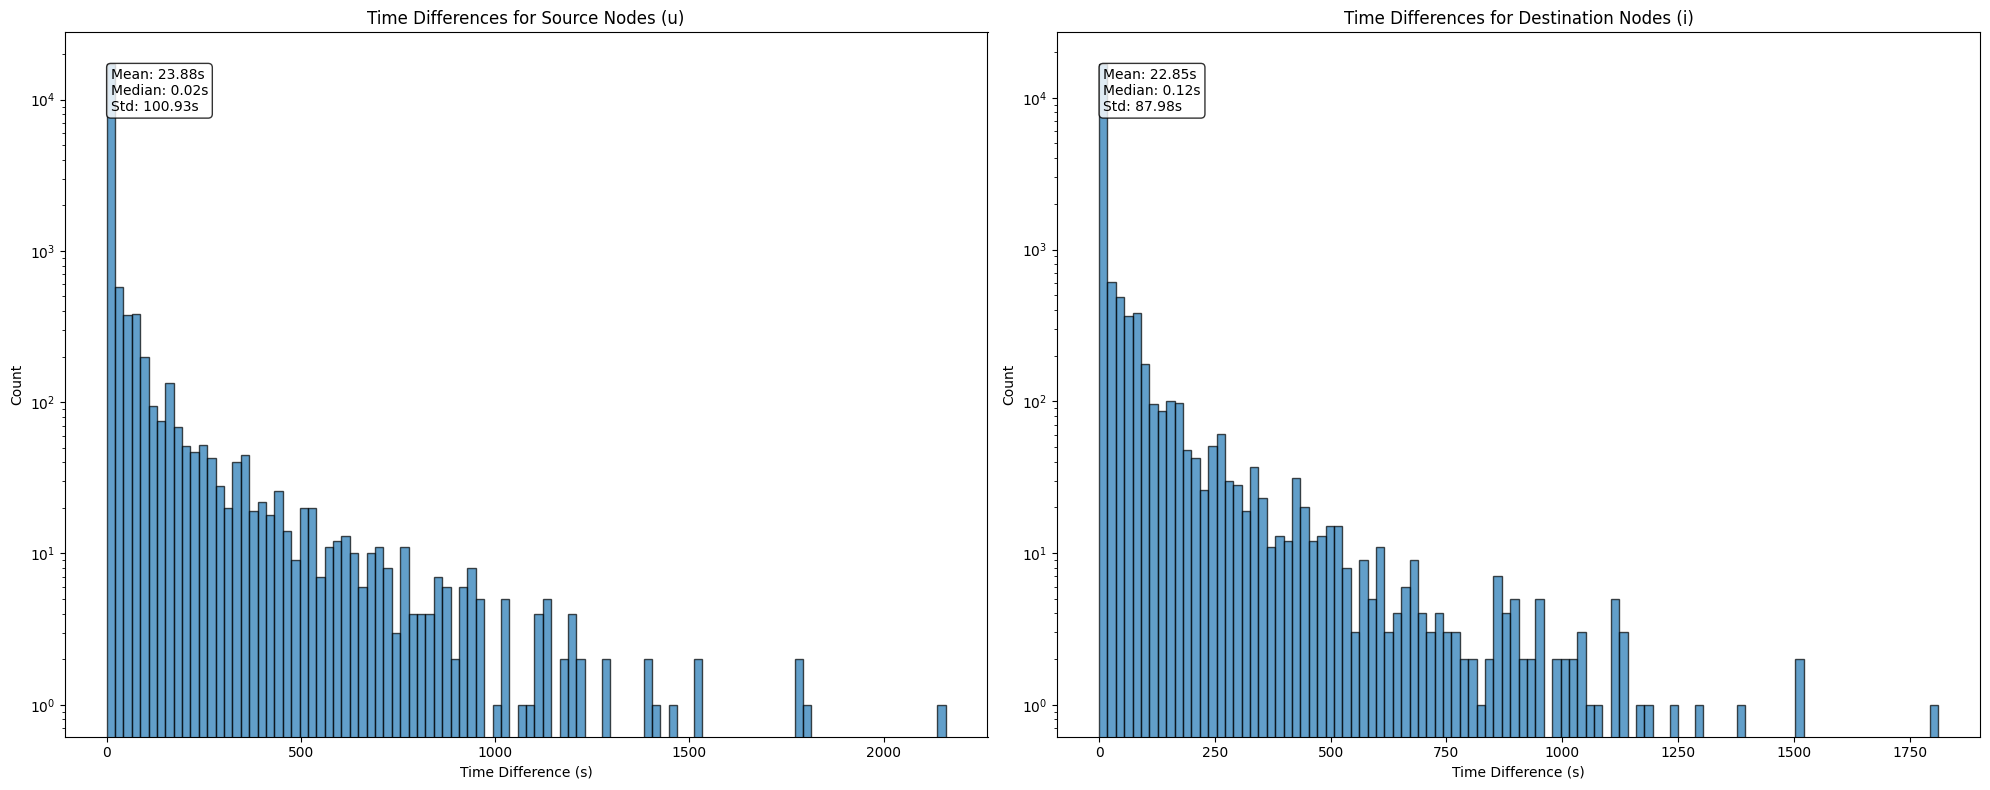

In [33]:
import matplotlib.pyplot as plt

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot for source nodes (u)
ns_df_u = ns_df.sort_values(['u', 'ts'])
ns_df_u['diff'] = ns_df_u.groupby(['u'])['ts'].diff().fillna(0)
ts_diffs_u = ns_df_u['diff'].dropna()

ax1.hist(ts_diffs_u/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
ax1.set_ylabel('Count')
ax1.set_xlabel('Time Difference (s)')
ax1.set_title('Time Differences for Source Nodes (u)')

# Calculate and display statistics for u
mean_diff_u = ts_diffs_u.mean()
median_diff_u = ts_diffs_u.median()
std_diff_u = ts_diffs_u.std()

ax1.text(0.05, 0.95, f'Mean: {mean_diff_u/1e3:.2f}s\nMedian: {median_diff_u/1e3:.2f}s\nStd: {std_diff_u/1e3:.2f}s', 
         transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot for destination nodes (i)
ns_df_i = ns_df.sort_values(['i', 'ts'])
ns_df_i['diff'] = ns_df_i.groupby(['i'])['ts'].diff().fillna(0)
ts_diffs_i = ns_df_i['diff'].dropna()

ax2.hist(ts_diffs_i/1e3, bins=100, edgecolor='black', alpha=0.7, log=True)
ax2.set_ylabel('Count')
ax2.set_xlabel('Time Difference (s)')
ax2.set_title('Time Differences for Destination Nodes (i)')

# Calculate and display statistics for i
mean_diff_i = ts_diffs_i.mean()
median_diff_i = ts_diffs_i.median()
std_diff_i = ts_diffs_i.std()

ax2.text(0.05, 0.95, f'Mean: {mean_diff_i/1e3:.2f}s\nMedian: {median_diff_i/1e3:.2f}s\nStd: {std_diff_i/1e3:.2f}s', 
         transform=ax2.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

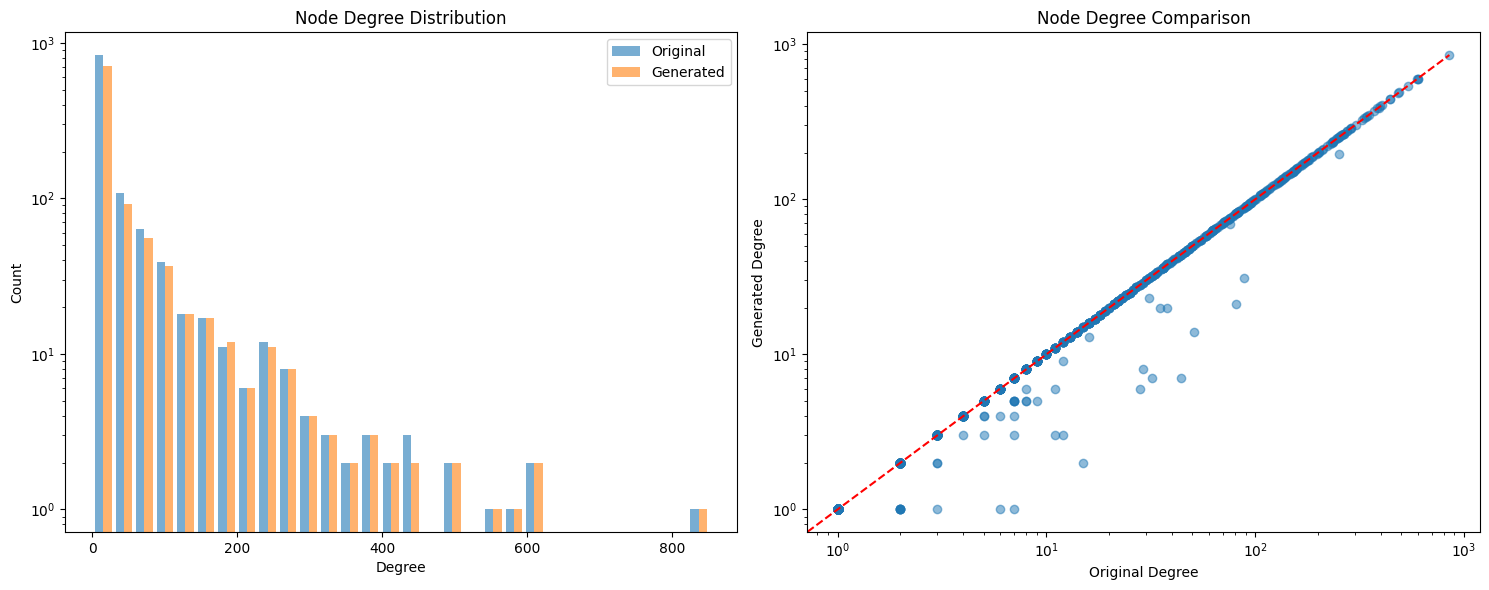


Degree Distribution Statistics:
Degree correlation: 0.979

Original Graph:
mean: 36.72
median: 8.00
std: 77.40
max: 851.00
min: 1.00

Generated Graph:
mean: 39.65
median: 8.00
std: 81.00
max: 851.00
min: 1.00

KL Divergence: 0.801


In [43]:
def plot_degree_comparison_nonbipartite(df1, df2, node_cols=['u', 'i']):
    """
    Visualize degree distribution comparison between two DataFrames for non-bipartite graphs
    
    Parameters:
    -----------
    df1, df2 : pandas.DataFrame
        DataFrames containing edge information
    node_cols : list
        Column names containing node IDs (default ['u', 'i'])
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Calculate unified degree distributions
    def get_degree_dist(df):
        degrees = Counter()
        for col in node_cols:
            degrees.update(Counter(df[col]))
        return degrees
    
    degrees1 = get_degree_dist(df1)
    degrees2 = get_degree_dist(df2)
    
    # Plot 1: Overall Node Degree Distribution
    degree_values1 = list(degrees1.values())
    degree_values2 = list(degrees2.values())
    
    ax1.hist([degree_values1, degree_values2], 
             label=['Original', 'Generated'], 
             alpha=0.6, bins=30)
    ax1.set_title('Node Degree Distribution')
    ax1.set_xlabel('Degree')
    ax1.set_ylabel('Count')
    ax1.set_yscale('log')  # Log scale for better visualization
    ax1.legend()
    
    # Plot 2: Degree Comparison Scatter
    x = sorted(set(degrees1.keys()) | set(degrees2.keys()))
    y1 = [degrees1.get(k, 0) for k in x]
    y2 = [degrees2.get(k, 0) for k in x]
    
    # y2 = [val2 if val1 == val2 else val2 for val1, val2 in zip(y1, y2)]


    
    
    ax2.scatter(y1, y2, alpha=0.5)
    ax2.plot([0, max(max(y1), max(y2))], [0, max(max(y1), max(y2))], 'r--')
    ax2.set_title('Node Degree Comparison')
    ax2.set_xlabel('Original Degree')
    ax2.set_ylabel('Generated Degree')
    ax2.set_xscale('log')  # Log scale for better visualization
    ax2.set_yscale('log')
    
    plt.tight_layout()
    # plt.savefig("NonBP_degree_dist.pdf", format="pdf", bbox_inches="tight")
    plt.show()
    
    # Additional statistics
    degree_corr = np.corrcoef(y1, y2)[0,1]
    
    # Calculate degree statistics
    def degree_stats(degrees):
        values = list(degrees.values())
        return {
            'mean': np.mean(values),
            'median': np.median(values),
            'std': np.std(values),
            'max': max(values),
            'min': min(values)
        }
    
    stats1 = degree_stats(degrees1)
    stats2 = degree_stats(degrees2)
    
    print("\nDegree Distribution Statistics:")
    print(f"Degree correlation: {degree_corr:.3f}")
    print("\nOriginal Graph:")
    for k, v in stats1.items():
        print(f"{k}: {v:.2f}")
    print("\nGenerated Graph:")
    for k, v in stats2.items():
        print(f"{k}: {v:.2f}")
    
    # Calculate KL divergence for degree distributions
    def calculate_kl_divergence(p, q):
        # Normalize distributions
        p_sum = sum(p)
        q_sum = sum(q)
        p_norm = [x/p_sum for x in p]
        q_norm = [x/q_sum for x in q]
        
        # Add small constant to avoid division by zero
        epsilon = 1e-10
        p_norm = [x + epsilon for x in p_norm]
        q_norm = [x + epsilon for x in q_norm]
        
        return sum(p * np.log(p/q) for p, q in zip(p_norm, q_norm))
    
    kl_div = calculate_kl_divergence(np.array(y1), np.array(y2))
    print(f"\nKL Divergence: {kl_div:.3f}")

# Usage
plot_degree_comparison_nonbipartite(all_missing_edges, ns_df)

In [29]:
def check_c3_compliance(df, negative_samples, W=1200):
    df_sorted = df.sort_values('ts')
    compliant = []
    for u, i, ts in negative_samples:
        # Find insertion point index
        insert_idx = df_sorted[df_sorted['ts'] <= ts].shape[0]
        # Get previous W edges
        window_start_idx = max(0, insert_idx - W*1e3)
        window_df = df_sorted.iloc[window_start_idx:insert_idx]
        # Get valid nodes from window
        nodes_in_window = set(window_df['u']) | set(window_df['i'])
        compliant.append((u in nodes_in_window) and (i in nodes_in_window))
    return compliant

In [ ]:
# compliant = check_c3_compliance_optimized(all_missing_edges, new_edges)
compliant = check_c3_compliance(all_missing_edges, new_edges, 1200)

plt.figure(figsize=(10, 6))
plt.plot(range(len(compliant)), compliant, 'b.')
plt.xlabel('Negative Sample Index')
plt.ylabel('C3 Compliant')
plt.title(f'(Our Method) C3 Compliance of Negative Samples: {sum(compliant)/len(compliant):.2%}')
plt.yticks([0, 1], ['No', 'Yes'])
plt.show()

## We are 100% C3-C4 compliant